In [192]:
# ===================================================
# NEURO-105: Statistics and Probability using Python
# Project: Mouse Cognition Study: Does Age Affect Object Recognition?
# Student: Georgia Koromila
# Date: 09.02.2026
# ===================================================

In [193]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [194]:
infile = "https://raw.githubusercontent.com/cgenomicslab/Courses/refs/heads/main/MScNeuro/2026/data/mouse_cognition.csv"
mice = pd.read_csv(infile)

In [195]:
display(mice.head(120))

,mouse_id,strain,maze_test,object_recognition,fear_conditioning,social_memory,BDNF,CREB1,DRD2,GRIN1,diet,light_hours,exercise_wheel,age_weeks,weight_g
0,M001,A,78,72,65,70,8.2,6.5,5.8,7.1,standard,12,yes,12,28.5
1,M002,A,82,75,68,73,8.5,6.8,5.6,7.4,standard,12,yes,14,29.2
2,M003,A,75,70,62,68,7.9,6.3,5.9,6.9,standard,12,no,11,27.8
3,M004,A,80,74,66,71,8.3,6.6,5.7,7.2,enriched,12,yes,13,28.1
4,M005,A,77,71,64,69,8.1,6.4,5.8,7.0,standard,12,no,12,28.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,M116,H,68,72,68,72,7.2,7.5,6.5,7.2,standard,12,no,12,26.1
116,M117,H,70,74,70,74,7.4,7.7,6.3,7.4,standard,12,yes,13,25.8
117,M118,H,66,70,66,70,7.0,7.3,6.7,7.0,high_fat,12,no,10,28.0
118,M119,H,74,78,74,78,7.8,8.1,6.0,7.8,enriched,12,yes,15,26.6


In [196]:
print("Shape:", mice.shape)
print("\nColumns:", list(mice.columns))

Shape: (120, 15)

Columns: ['mouse_id', 'strain', 'maze_test', 'object_recognition', 'fear_conditioning', 'social_memory', 'BDNF', 'CREB1', 'DRD2', 'GRIN1', 'diet', 'light_hours', 'exercise_wheel', 'age_weeks', 'weight_g']


In [197]:
mice_subset = variables = mice[['age_weeks', 'object_recognition']]

In [198]:
print("=== VARIABLES OF INTEREST ===")
print(f"Selected 2 out of {mice.shape[1]} total columns")
display(variables.head(10))  # Show first 10 rows
display(variables.tail(10))   # Show last 10 rows

=== VARIABLES OF INTEREST ===
Selected 2 out of 15 total columns


,age_weeks,object_recognition
0,12,72
1,14,75
2,11,70
3,13,74
4,12,71
5,15,76
6,10,69
7,13,73
8,14,74
9,11,68


,age_weeks,object_recognition
110,15,76
111,10,68
112,13,74
113,14,77
114,11,67
115,12,72
116,13,74
117,10,70
118,15,78
119,12,73


In [199]:
data = data.dropna()
print("Number of observations:", data.shape[0])
print("Descriptive Statistics for columns of interest")
display(mice[['age_weeks', 'object_recognition']].describe())

Number of observations: 32
Descriptive Statistics for columns of interest


,age_weeks,object_recognition
count,120.000000,120.000000
mean,12.466667,70.550000
std,1.549916,6.900067
min,10.000000,53.000000
25%,11.000000,66.750000
50%,12.000000,71.000000
75%,14.000000,75.000000
max,15.000000,86.000000


In [200]:
print("Missing values")
print(mice[['age_weeks', 'object_recognition']].isna().sum())

Missing values
age_weeks             0
object_recognition    0
dtype: int64


In [201]:
from scipy import stats

shapiro_age = stats.shapiro(data['age_weeks'])
shapiro_obj = stats.shapiro(data['object_recognition'])

print("Shapiro age_weeks:", shapiro_age)
print("Shapiro object_recognition:", shapiro_obj)

Shapiro age_weeks: ShapiroResult(statistic=np.float64(0.6379591276330898), pvalue=np.float64(1.1587671773193818e-07))
Shapiro object_recognition: ShapiroResult(statistic=np.float64(0.9666056248213334), pvalue=np.float64(0.4113652817510298))


In [202]:
alpha = 0.05

if shapiro_age.pvalue > alpha and shapiro_obj.pvalue > alpha:
    # Both variables approximately normal
    r, p = stats.pearsonr(data['age_weeks'], data['object_recognition'])
    test_used = "Pearson correlation"
else:
    # At least one variable not normal
    r, p = stats.spearmanr(data['age_weeks'], data['object_recognition'])
    test_used = "Spearman correlation"

print(test_used)
print("Correlation coefficient (r):", r)
print("p-value:", p)

Spearman correlation
Correlation coefficient (r): 0.10512401227922046
p-value: 0.5669141473630925


Variable visualization


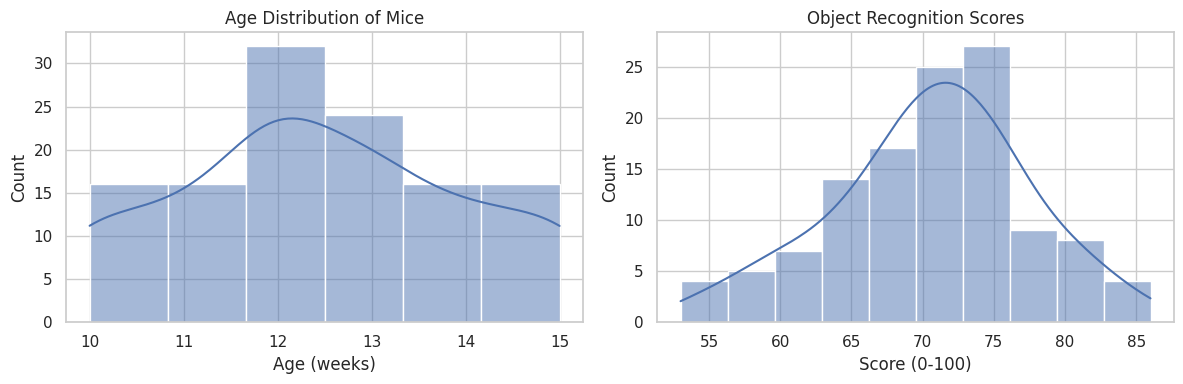

In [203]:
print("Variable visualization")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Age distribution
sns.histplot(data=mice, x='age_weeks', bins=6, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution of Mice')
axes[0].set_xlabel('Age (weeks)')
axes[0].set_ylabel('Count')

# Right: Object recognition distribution
sns.histplot(data=mice, x='object_recognition', bins=10, kde=True, ax=axes[1])
axes[1].set_title('Object Recognition Scores')
axes[1].set_xlabel('Score (0-100)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [204]:
from scipy.stats import pearsonr, linregress

# Calculate Pearson correlation coefficient
correlation, p_value_corr = pearsonr(mice['age_weeks'], mice['object_recognition'])
print(f"### Statistical Analysis: Pearson Correlation Coefficient")
print(f"Correlation between age_weeks and object_recognition: {correlation:.3f}")
print(f"P-value for correlation: {p_value_corr:.3f}")

# Perform Linear Regression
# slope, intercept, r_value, p_value_reg, stderr = linregress(mice['age_weeks'], mice['object_recognition'])
lin_reg = linregress(mice['age_weeks'], mice['object_recognition'])
slope, intercept, r_value, p_value_reg, stderr = lin_reg

print("\n### Statistical Analysis: Linear Regression")
print(f"Regression Equation: Object_Recognition = {slope:.3f} * Age_Weeks + {intercept:.3f}")
print(f"R-squared: {r_value**2:.3f}")
print(f"P-value for regression (slope significance): {p_value_reg:.3f}")
print(f"Standard Error of the slope: {stderr:.3f}")

### Statistical Analysis: Pearson Correlation Coefficient
Correlation between age_weeks and object_recognition: 0.406
P-value for correlation: 0.000

### Statistical Analysis: Linear Regression
Regression Equation: Object_Recognition = 1.809 * Age_Weeks + 47.995
R-squared: 0.165
P-value for regression (slope significance): 0.000
Standard Error of the slope: 0.374


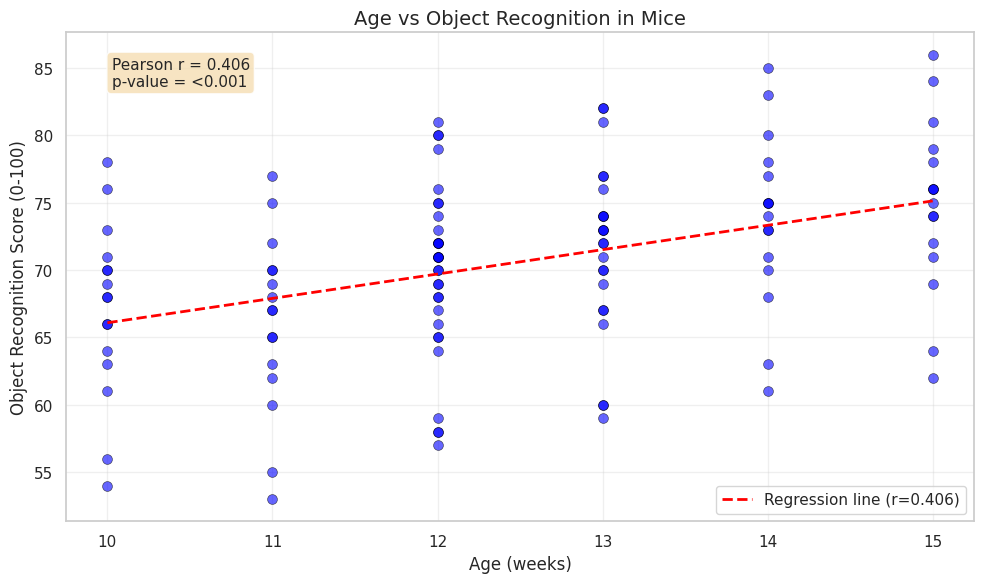

In [205]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up the plot
plt.figure(figsize=(10, 6))

# Create scatter plot
plt.scatter(mice['age_weeks'],
            mice['object_recognition'],
            s=50,           # Size of dots
            alpha=0.6,      # Transparency
            color='blue',   # Color
            edgecolor='black',  # Edge color
            linewidth=0.5)  # Edge width

# Add regression line
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(mice['age_weeks'],
                                                               mice['object_recognition'])
# Create line
x_values = np.array([mice['age_weeks'].min(), mice['age_weeks'].max()])
y_values = intercept + slope * x_values
plt.plot(x_values, y_values, color='red', linewidth=2, linestyle='--',
         label=f'Regression line (r={r_value:.3f})')

# Customize
plt.title('Age vs Object Recognition in Mice', fontsize=14)
plt.xlabel('Age (weeks)', fontsize=12)
plt.ylabel('Object Recognition Score (0-100)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Format p-value: show as "<0.001" if less than 0.001
if p_value < 0.001:
    p_display = "<0.001"
else:
    p_display = f"{p_value:.4f}"

# Add correlation coefficient text with formatted p-value
plt.text(0.05, 0.95, f'Pearson r = {r_value:.3f}\np-value = {p_display}',
         transform=plt.gca().transAxes,
         fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

**Conclusion**: Age significantly predicts object recognition performance (r = 0.406, p < 0.001), explaining 16.5% of variance. Object recognition scores increase by approximately 1.8 points per week of age, indicating a moderate positive relationship where older mice consistently score higher.